In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.timeseries import TimeSeries

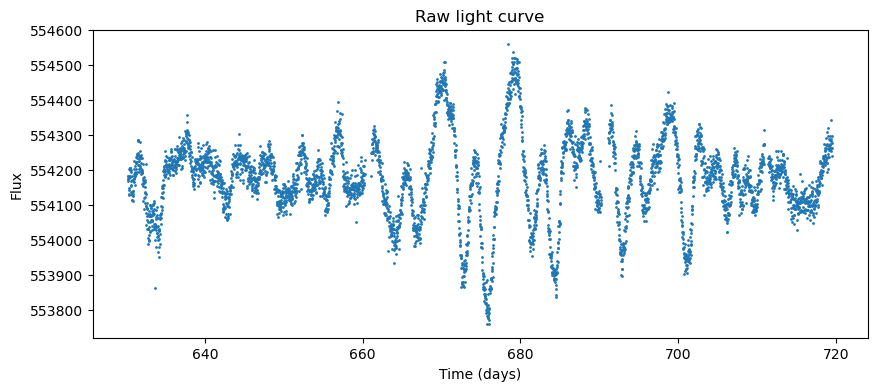

In [2]:
import os
os.chdir("/Users/adarsh/Downloads/")
hdul = fits.open("kplr004818131-2010355172524_llc.fits")
data = hdul[1].data

time = data["TIME"]
flux = data["PDCSAP_FLUX"]

plt.figure(figsize=(10,4))
plt.scatter(time, flux, s=1)
plt.xlabel("Time (days)")
plt.ylabel("Flux")
plt.title("Raw light curve")
plt.show()

In [3]:
time_arr = np.array(time)
flux_arr = np.array(flux)

mask = np.isfinite(time_arr) & np.isfinite(flux_arr)

time_clean = time_arr[mask]
flux_clean = flux_arr[mask]

In [4]:
from scipy.signal import medfilt
flux64 = flux_clean.astype(np.float64)
smooth = medfilt(flux64, kernel_size=101)
flux_detrended = flux64 / smooth

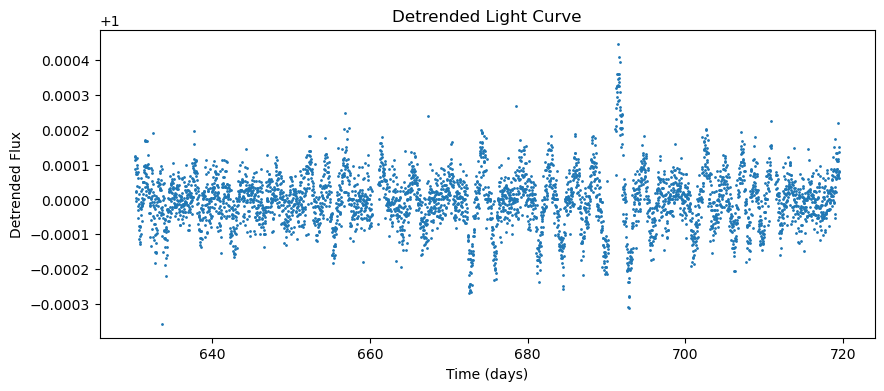

In [5]:
plt.figure(figsize=(10,4))
plt.scatter(time_clean, flux_detrended, s=1)
plt.xlabel("Time (days)")
plt.ylabel("Detrended Flux")
plt.title("Detrended Light Curve")
plt.show()

In [6]:
from scipy.signal import find_peaks
inv_flux = 1.0 - flux_detrended
peaks, props = find_peaks(inv_flux, prominence=0.0002)
transit_times = time_clean[peaks]
print("Number of candidate dips:", len(peaks))
print("First few dip times:", transit_times[:10])

Number of candidate dips: 54
First few dip times: [630.86966388 632.25909545 632.74948275 633.66895884 634.11848035
 638.61369062 639.34926976 641.08605285 642.78196951 646.58245375]


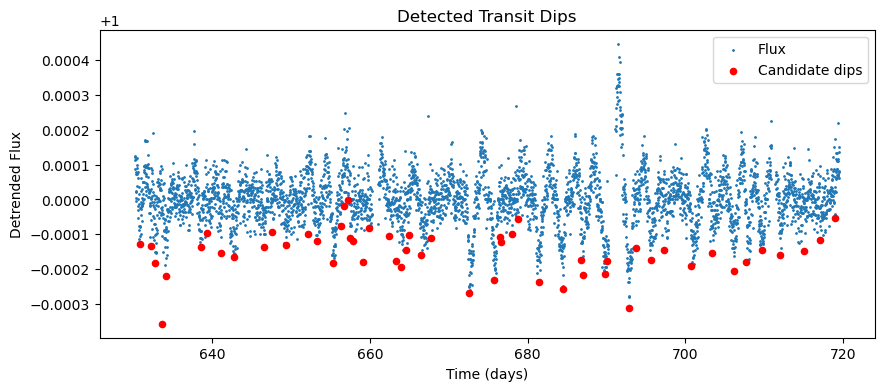

In [7]:
plt.figure(figsize=(10,4))
plt.scatter(time_clean, flux_detrended, s=1, label="Flux")
plt.scatter(time_clean[peaks], flux_detrended[peaks], color="red", s=20, label="Candidate dips")
plt.xlabel("Time (days)")
plt.ylabel("Detrended Flux")
plt.title("Detected Transit Dips")
plt.legend()
plt.show()

First few Δt values: [1.38943158 0.4903873  0.91947609 0.44952151 4.49521027 0.73557914
 1.73678309 1.69591666 3.80048425 1.04206749]


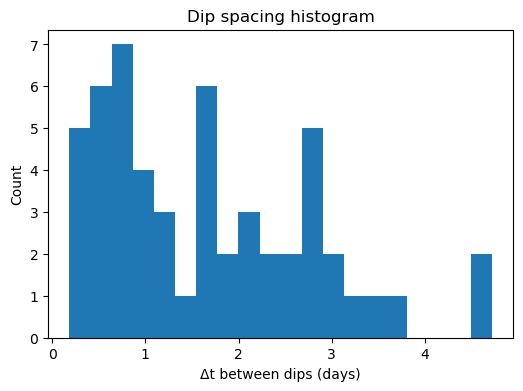

In [8]:
transit_times = np.sort(transit_times)
transit_difference = np.diff(transit_times)
print("First few Δt values:", transit_difference[:10])
plt.figure(figsize=(6,4))
plt.hist(transit_difference, bins=20)
plt.xlabel("Δt between dips (days)")
plt.ylabel("Count")
plt.title("Dip spacing histogram")
plt.show()

In [9]:
period_guess = np.median(transit_difference)
print("Rough period guess:", period_guess)

Rough period guess: 1.5733126466948306


In [10]:
from astropy.timeseries import BoxLeastSquares
x = time_clean
y = flux_detrended
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]
periods = np.linspace(0.5 * period_guess, 1.5 * period_guess, 500)
bls = BoxLeastSquares(x, y)
result = bls.power(periods, 0.001)
best_idx = np.argmax(result.power)
best_period = result.period[best_idx]
best_initial_time = result.transit_time[best_idx]
print("Best period (days):", best_period)
print("Best initial transit time:", best_initial_time)

Best period (days): 2.161334307233079
Best initial transit time: 631.5078806245074
